In [1]:
import sys
import os

print(f"Current Python Executable: {sys.executable}")
print(f"Current Working Directory: {os.getcwd()}")

# Verify if we are in the correct environment (optional check)
expected_env = "NirEnV"
if expected_env.lower() in sys.executable.lower():
    print(f"✅ Running in expected environment: {expected_env}")
else:
    print(f"⚠️ Warning: It seems you are not running in the '{expected_env}' environment.")


Current Python Executable: d:\CUDA_Experiments\AgriCast\Scripts\python.exe
Current Working Directory: d:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2
⚠️ Warning: It seems you are not running in the 'NirEnV' environment.


# AgriCast360 - Feature Engineering

**Objective:** Build a comprehensive feature set for crop price prediction.
**Inputs:**
- Consolidated Mandi Data (Historical Prices & Arrivals)
- Consolidated Weather Data (Temperature, Rainfall, etc.)

**Key Features to Build:**
1.  **Temporal Features:** Seasonality, Trends.
2.  **Lag Features:** Past prices (Autoregressive features).
3.  **Weather Features:** Rolling averages of weather conditions affecting crop yield and supply.
4.  **Interaction Features:** Market-Crop specifics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Define Paths
ROOT_FOLDER = Path(r"D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2")
EDA_RESULTS_FOLDER = ROOT_FOLDER / "EDA_Results"
MANDI_DATA_PATH = EDA_RESULTS_FOLDER / "Mandi" / "Overall" / "combined_mandi_data.csv"
WEATHER_DATA_PATH = EDA_RESULTS_FOLDER / "Weather" / "Overall" / "combined_weather_data.csv"

print("✅ Libraries imported and paths defined.")

✅ Libraries imported and paths defined.


In [3]:
# Load Data
print("⏳ Loading data...")
df_mandi = pd.read_csv(MANDI_DATA_PATH)
df_weather = pd.read_csv(WEATHER_DATA_PATH)

print(f"✅ Mandi Data Loaded: {df_mandi.shape}")
print(f"✅ Weather Data Loaded: {df_weather.shape}")

# Display first few rows to verify
display(df_mandi.head(3))
display(df_weather.head(3))

⏳ Loading data...
✅ Mandi Data Loaded: (84549, 11)
✅ Weather Data Loaded: (11820, 58)


,State,District,Market,Commodity,Variety,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Source_Mandi
0,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-08,1200,3300,2950,154,Ahmedabad
1,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-10,1500,3800,3050,154,Ahmedabad
2,Gujarat,Ahmedabad,Ahmedabad (Vasana),Cabbage,Other,2024-07-13,2000,3800,3100,154,Ahmedabad


,clouds (%),Date,dewpt (°C),dhi (W/m²),dni (W/m²),ghi (W/m²),max_dhi (W/m²),max_dni (W/m²),max_ghi (W/m²),max_temp (°C),max_uv (Index),max_wind_dir (°),max_wind_spd (m/s),min_temp (°C),precip (mm),precip_gpm (mm/hr),pres (hPa),rh (%),slp (hPa),solar_rad (W/m²),temp (°C),wind_dir (°),wind_gust_spd (m/s),wind_spd (m/s),market_name (Text),query_lat (°),query_lon (°),Source_Location,clouds,datetime,dewpt,dhi,dni,ghi,max_dhi,max_dni,max_ghi,max_temp,max_uv,max_wind_dir,max_wind_spd,min_temp,precip,precip_gpm,pres,rh,slp,solar_rad,t_dhi,t_dni,t_ghi,t_solar_rad,temp,ts,wind_dir,wind_gust_spd,wind_spd,Market
0,0.00,2024-01-01,15.8,40.0,331.0,204.0,114.0,901.0,730.0,27.4,5.8,89.0,3.8,15.2,0.0,0.0,1009.0,0.74,1014.0,204.0,20.9,89.0,4.8,2.1,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.01,2024-02-01,15.3,40.0,331.0,205.0,114.0,902.0,731.0,25.0,5.9,61.0,4.1,16.0,0.0,0.0,1009.0,0.75,1014.0,205.0,20.0,61.0,6.0,2.7,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.01,2024-03-01,12.5,40.0,331.0,205.0,114.0,902.0,733.0,26.0,5.7,88.0,4.5,14.0,0.0,0.0,1008.0,0.67,1013.0,205.0,19.5,88.0,6.8,2.9,Ahmedabad_Chimanbhai_Patal_Market_Vasana,22.996977,72.536392,Ahmedabad_(Vasana),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data Preprocessing & Cleaning

- Standardize Date columns.
- Clean Column names.
- Create a common `Location_Key` for merging.

In [4]:
# 1. Clean Column Names
df_mandi.columns = [col.strip() for col in df_mandi.columns]
df_weather.columns = [col.strip() for col in df_weather.columns]

# 2. Standardize Date Columns
# Mandi: 'Arrival_Date' -> datetime
df_mandi['Date'] = pd.to_datetime(df_mandi['Arrival_Date'])

# Weather: 'Date' or 'datetime' -> datetime
# Check which column exists and is populated
if 'Date' in df_weather.columns:
    df_weather['Date'] = pd.to_datetime(df_weather['Date'])
elif 'datetime' in df_weather.columns:
    df_weather['Date'] = pd.to_datetime(df_weather['datetime'])

# 3. Create Location Key for Merging
# Mandi Source: 'Ahmedabad', 'Amreli', 'Surat'
# Weather Source: 'Ahmedabad_(Vasana)', 'Amreli', 'Surat', etc.

def normalize_location(loc_name):
    if pd.isna(loc_name):
        return "unknown"
    loc_name = str(loc_name).lower()
    if 'ahmedabad' in loc_name:
        return 'ahmedabad'
    elif 'amreli' in loc_name:
        return 'amreli'
    elif 'surat' in loc_name:
        return 'surat'
    # Add more mappings if needed based on other weather files
    return loc_name.split('_')[0] # Fallback: take first part before underscore

df_mandi['Location_Key'] = df_mandi['Source_Mandi'].apply(normalize_location)
df_weather['Location_Key'] = df_weather['Source_Location'].apply(normalize_location)

print("Unique Mandi Locations:", df_mandi['Location_Key'].unique())
print("Unique Weather Locations (mapped):", df_weather['Location_Key'].unique())

# Filter Weather data to only include locations present in Mandi data
valid_locations = df_mandi['Location_Key'].unique()
df_weather_filtered = df_weather[df_weather['Location_Key'].isin(valid_locations)].copy()

print(f"Filtered Weather Data Shape: {df_weather_filtered.shape}")

Unique Mandi Locations: ['ahmedabad' 'amreli' 'surat']
Unique Weather Locations (mapped): ['ahmedabad' 'amreli' 'babra' 'bagasara' 'bardoli' 'bavla' 'dhandhuka'
 'dhari' 'dholka' 'kosamba' 'mahuva' 'mandal' 'mandvi' 'nizar' 'rajula'
 'sanad' 'savarkundla' 'songadh' 'surat' 'uchhal' 'valod' 'viramgam'
 'vyara' 'vyra']
Filtered Weather Data Shape: (1098, 59)


## 2. Mandi Feature Engineering (Advanced)

**Goal:** Capture price trends, seasonality, and market momentum.

- **Cyclical Time Features:** Sine/Cosine encoding for Month and DayOfYear.
- **Technical Indicators:**
    - **RSI (Relative Strength Index):** Momentum indicator (Overbought/Oversold).
    - **Bollinger Bands:** Volatility indicator.
    - **MACD:** Trend following momentum.
    - **EMA (Exponential Moving Average):** Weighted recent price trends.
- **Lags & Rolling Stats:** Standard historical context.

In [5]:
# Sort data for time-series calculations
df_mandi = df_mandi.sort_values(by=['Location_Key', 'Commodity', 'Variety', 'Date'])

# 1. Date Features (Cyclical Encoding)
# Capture the cyclical nature of time (Jan is close to Dec)
df_mandi['Month_Sin'] = np.sin(2 * np.pi * df_mandi['Date'].dt.month / 12)
df_mandi['Month_Cos'] = np.cos(2 * np.pi * df_mandi['Date'].dt.month / 12)
df_mandi['DayOfYear_Sin'] = np.sin(2 * np.pi * df_mandi['Date'].dt.dayofyear / 365)
df_mandi['DayOfYear_Cos'] = np.cos(2 * np.pi * df_mandi['Date'].dt.dayofyear / 365)

# Basic Date Parts
df_mandi['Year'] = df_mandi['Date'].dt.year
df_mandi['Month'] = df_mandi['Date'].dt.month
df_mandi['WeekOfYear'] = df_mandi['Date'].dt.isocalendar().week

# 2. Advanced Price Features (Lags, Rolling, Technical Indicators)
groupby_cols = ['Location_Key', 'Commodity', 'Variety']

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def create_advanced_price_features(df):
    df = df.copy()
    
    # Group object for efficiency
    grouped = df.groupby(groupby_cols)['Modal_Price']
    
    # --- Lags ---
    for lag in [1, 3, 7, 14, 30]:
        df[f'Price_Lag_{lag}d'] = grouped.shift(lag)
        
    # --- Rolling Statistics ---
    for window in [7, 30]:
        # Shift by 1 to avoid data leakage
        df[f'Price_RollMean_{window}d'] = grouped.transform(lambda x: x.shift(1).rolling(window).mean())
        df[f'Price_RollStd_{window}d'] = grouped.transform(lambda x: x.shift(1).rolling(window).std())
        
    # --- Exponential Moving Averages (EMA) ---
    # EMA gives more weight to recent prices
    df['Price_EMA_7d'] = grouped.transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
    df['Price_EMA_30d'] = grouped.transform(lambda x: x.shift(1).ewm(span=30, adjust=False).mean())
    
    # --- Technical Indicators ---
    
    # 1. RSI (Relative Strength Index) - Momentum
    df['Price_RSI_14d'] = grouped.transform(lambda x: calculate_rsi(x.shift(1), period=14))
    
    # 2. Bollinger Bands - Volatility
    # Upper = SMA + 2*STD, Lower = SMA - 2*STD
    df['BB_Upper'] = df['Price_RollMean_30d'] + (2 * df['Price_RollStd_30d'])
    df['BB_Lower'] = df['Price_RollMean_30d'] - (2 * df['Price_RollStd_30d'])
    # %B Indicator: Where is the price relative to bands?
    df['BB_PctB'] = (df['Price_Lag_1d'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
    
    # 3. MACD (Moving Average Convergence Divergence) - Trend
    # MACD = EMA_12 - EMA_26
    ema_12 = grouped.transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean())
    ema_26 = grouped.transform(lambda x: x.shift(1).ewm(span=26, adjust=False).mean())
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df.groupby(groupby_cols)['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    
    return df

print("⏳ Generating Advanced Mandi features...")
df_mandi_features = create_advanced_price_features(df_mandi)

print(f"✅ Mandi Features Created. New Shape: {df_mandi_features.shape}")
display(df_mandi_features[['Date', 'Modal_Price', 'Price_RSI_14d', 'MACD', 'BB_PctB']].tail())

⏳ Generating Advanced Mandi features...
✅ Mandi Features Created. New Shape: (84549, 37)


,Date,Modal_Price,Price_RSI_14d,MACD,BB_PctB
60755,2024-04-04,2445,54.852484,84.229142,NaN
59396,2024-04-06,2250,55.783656,99.768903,NaN
60209,2024-04-08,2250,56.227616,95.251406,NaN
60210,2024-04-09,2350,50.113379,90.626571,NaN
57394,2024-05-23,2300,61.479592,93.947551,NaN


## 3. Weather Feature Engineering (Advanced)

**Goal:** Capture environmental stress and cumulative effects.

- **Rolling Averages:** 7, 15, 30, 90 days (Short to Long term impact).
- **Weather Anomalies:** Deviation from the 30-day rolling mean (e.g., sudden heatwave).
- **Interaction Features:**
    - **Heat Index Proxy:** Temp * Humidity.
    - **Storm Index:** Precip * Wind Speed.

In [6]:
# Select relevant weather columns
print("Available Weather Columns:", df_weather_filtered.columns.tolist())

weather_cols_map = {
    'temp': ['temp (°C)', 'temp'],
    'precip': ['precip (mm)', 'precip'],
    'rh': ['rh (%)', 'rh'],
    'wind_spd': ['wind_spd (m/s)', 'wind_spd'],
    'solar_rad': ['solar_rad (W/m²)', 'solar_rad']
}

selected_weather_cols = ['Date', 'Location_Key']
rename_map = {}

for target, candidates in weather_cols_map.items():
    for cand in candidates:
        if cand in df_weather_filtered.columns:
            selected_weather_cols.append(cand)
            rename_map[cand] = target
            break

df_weather_clean = df_weather_filtered[selected_weather_cols].copy()
df_weather_clean = df_weather_clean.rename(columns=rename_map)

# Aggregate duplicates
df_weather_daily = df_weather_clean.groupby(['Location_Key', 'Date']).mean().reset_index()
df_weather_daily = df_weather_daily.sort_values(by=['Location_Key', 'Date'])

# --- Advanced Weather Features ---

weather_vars = [v for v in ['temp', 'precip', 'rh', 'wind_spd', 'solar_rad'] if v in df_weather_daily.columns]

for var in weather_vars:
    # 1. Rolling Means (Cumulative effect)
    for window in [7, 15, 30, 90]:
        df_weather_daily[f'{var}_RollMean_{window}d'] = df_weather_daily.groupby('Location_Key')[var].transform(lambda x: x.shift(1).rolling(window).mean())
    
    # 2. Weather Anomalies (Deviation from recent norm)
    # Is today hotter/wetter than the last 30 days average?
    df_weather_daily[f'{var}_Anomaly_30d'] = df_weather_daily[var] - df_weather_daily[f'{var}_RollMean_30d']

# 3. Interaction Features
# Heat Index Proxy: Temp * Humidity (High temp + High humidity = Stress)
if 'temp' in df_weather_daily.columns and 'rh' in df_weather_daily.columns:
    df_weather_daily['Heat_Index_Proxy'] = df_weather_daily['temp'] * df_weather_daily['rh']

# Rainfall Intensity: Rain * Wind (Storminess)
if 'precip' in df_weather_daily.columns and 'wind_spd' in df_weather_daily.columns:
    df_weather_daily['Storm_Index'] = df_weather_daily['precip'] * df_weather_daily['wind_spd']

print(f"✅ Advanced Weather Features Created. Shape: {df_weather_daily.shape}")
display(df_weather_daily.tail())

Available Weather Columns: ['clouds (%)', 'Date', 'dewpt (°C)', 'dhi (W/m²)', 'dni (W/m²)', 'ghi (W/m²)', 'max_dhi (W/m²)', 'max_dni (W/m²)', 'max_ghi (W/m²)', 'max_temp (°C)', 'max_uv (Index)', 'max_wind_dir (°)', 'max_wind_spd (m/s)', 'min_temp (°C)', 'precip (mm)', 'precip_gpm (mm/hr)', 'pres (hPa)', 'rh (%)', 'slp (hPa)', 'solar_rad (W/m²)', 'temp (°C)', 'wind_dir (°)', 'wind_gust_spd (m/s)', 'wind_spd (m/s)', 'market_name (Text)', 'query_lat (°)', 'query_lon (°)', 'Source_Location', 'clouds', 'datetime', 'dewpt', 'dhi', 'dni', 'ghi', 'max_dhi', 'max_dni', 'max_ghi', 'max_temp', 'max_uv', 'max_wind_dir', 'max_wind_spd', 'min_temp', 'precip', 'precip_gpm', 'pres', 'rh', 'slp', 'solar_rad', 't_dhi', 't_dni', 't_ghi', 't_solar_rad', 'temp', 'ts', 'wind_dir', 'wind_gust_spd', 'wind_spd', 'Market', 'Location_Key']
✅ Advanced Weather Features Created. Shape: (654, 34)


,Location_Key,Date,temp,precip,rh,wind_spd,solar_rad,temp_RollMean_7d,temp_RollMean_15d,temp_RollMean_30d,temp_RollMean_90d,temp_Anomaly_30d,precip_RollMean_7d,precip_RollMean_15d,precip_RollMean_30d,precip_RollMean_90d,precip_Anomaly_30d,rh_RollMean_7d,rh_RollMean_15d,rh_RollMean_30d,rh_RollMean_90d,rh_Anomaly_30d,wind_spd_RollMean_7d,wind_spd_RollMean_15d,wind_spd_RollMean_30d,wind_spd_RollMean_90d,wind_spd_Anomaly_30d,solar_rad_RollMean_7d,solar_rad_RollMean_15d,solar_rad_RollMean_30d,solar_rad_RollMean_90d,solar_rad_Anomaly_30d,Heat_Index_Proxy,Storm_Index
649,surat,2024-12-27,23.4,0.0,0.77,1.4,201.0,22.171429,22.426667,23.620000,26.925556,-0.220000,0.0,0.0,0.01,2.320000,-0.01,0.698571,0.614667,0.558667,0.649000,0.211333,1.557143,1.380000,1.636667,1.786667,-0.236667,190.428571,194.600000,201.466667,219.700000,-0.466667,18.018,0.0
650,surat,2024-12-28,22.0,0.0,0.77,1.4,214.0,22.428571,22.493333,23.546667,26.893333,-1.546667,0.0,0.0,0.01,1.703333,-0.01,0.712857,0.628667,0.569667,0.646778,0.200333,1.542857,1.400000,1.626667,1.768889,-0.226667,200.571429,193.866667,200.700000,221.322222,13.300000,16.940,0.0
651,surat,2024-12-29,23.1,0.0,0.75,1.1,214.0,22.400000,22.446667,23.446667,26.843333,-0.346667,0.0,0.0,0.01,1.655556,-0.01,0.721429,0.649333,0.578000,0.644889,0.172000,1.557143,1.413333,1.573333,1.767778,-0.473333,200.714286,201.600000,200.400000,222.755556,13.600000,17.325,0.0
652,surat,2024-12-30,24.0,0.0,0.74,0.9,215.0,22.457143,22.446667,23.386667,26.782222,0.613333,0.0,0.0,0.01,1.646667,-0.01,0.714286,0.669333,0.588667,0.643556,0.151333,1.328571,1.406667,1.556667,1.770000,-0.656667,204.000000,201.600000,200.133333,222.055556,14.866667,17.760,0.0
653,surat,2024-12-31,24.1,0.0,0.71,0.8,214.0,22.600000,22.460000,23.373333,26.718889,0.726667,0.0,0.0,0.01,1.541111,-0.01,0.721429,0.688000,0.598667,0.642444,0.111333,1.171429,1.393333,1.546667,1.757778,-0.746667,205.714286,201.733333,199.933333,221.122222,14.066667,17.111,0.0


## 4. Merging & Final Dataset Creation

- Merge Mandi Features with Weather Features on `Location_Key` and `Date`.
- Handle missing values (forward fill weather if needed, or drop).

In [7]:
# === Agricultural Domain Features ===
print("⏳ Building Agricultural Domain Features...")

# 1. Growing Degree Days (GDD) - Heat accumulation for crop growth
# Base temperature varies by crop, using 10°C as general threshold
if 'temp' in df_weather_daily.columns:
    df_weather_daily['GDD_Daily'] = df_weather_daily['temp'].apply(lambda x: max(x - 10, 0))
    # Cumulative GDD over growing windows
    for window in [30, 60, 90]:
        df_weather_daily[f'GDD_Cumulative_{window}d'] = df_weather_daily.groupby('Location_Key')['GDD_Daily'].transform(
            lambda x: x.rolling(window).sum()
        )

# 2. Drought Stress Index - Consecutive days with low rainfall
if 'precip' in df_weather_daily.columns:
    # Days with rainfall < 1mm (considered dry)
    df_weather_daily['Is_Dry_Day'] = (df_weather_daily['precip'] < 1).astype(int)
    
    # Calculate consecutive dry days
    df_weather_daily['Consecutive_Dry_Days'] = (
        df_weather_daily.groupby('Location_Key')['Is_Dry_Day']
        .transform(lambda x: x.groupby((x != x.shift()).cumsum()).cumsum())
    )
    
    # Rainfall deficit from 30-day average
    df_weather_daily['Rainfall_Deficit_30d'] = (
        df_weather_daily['precip_RollMean_30d'] - df_weather_daily['precip']
    )

# 3. Extreme Weather Events
if 'temp' in df_weather_daily.columns:
    # Heatwave indicator (temp > 35°C)
    df_weather_daily['Heatwave_Day'] = (df_weather_daily['temp'] > 35).astype(int)
    df_weather_daily['Heatwave_Count_30d'] = df_weather_daily.groupby('Location_Key')['Heatwave_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

if 'precip' in df_weather_daily.columns:
    # Heavy rainfall event (>20mm/day)
    df_weather_daily['Heavy_Rain_Day'] = (df_weather_daily['precip'] > 20).astype(int)
    df_weather_daily['Heavy_Rain_Count_30d'] = df_weather_daily.groupby('Location_Key')['Heavy_Rain_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

# 4. Vapor Pressure Deficit (VPD) - Plant water stress indicator
# Approximation: VPD depends on temp and humidity
if 'temp' in df_weather_daily.columns and 'rh' in df_weather_daily.columns:
    # Saturation vapor pressure (simplified formula)
    df_weather_daily['VPD'] = (
        0.6108 * np.exp((17.27 * df_weather_daily['temp']) / (df_weather_daily['temp'] + 237.3)) * 
        (1 - df_weather_daily['rh'] / 100)
    )
    df_weather_daily['VPD_RollMean_30d'] = df_weather_daily.groupby('Location_Key')['VPD'].transform(
        lambda x: x.shift(1).rolling(30).mean()
    )

# 5. Solar Radiation Stress
if 'solar_rad' in df_weather_daily.columns:
    # Low light days (cloudy, affects photosynthesis)
    df_weather_daily['Low_Light_Day'] = (df_weather_daily['solar_rad'] < 100).astype(int)
    df_weather_daily['Low_Light_Count_30d'] = df_weather_daily.groupby('Location_Key')['Low_Light_Day'].transform(
        lambda x: x.rolling(30).sum()
    )

print(f"✅ Agricultural Domain Features Added. Shape: {df_weather_daily.shape}")
display(df_weather_daily[['Date', 'Location_Key', 'GDD_Cumulative_90d', 'Consecutive_Dry_Days', 'VPD']].tail())

⏳ Building Agricultural Domain Features...
✅ Agricultural Domain Features Added. Shape: (654, 49)


,Date,Location_Key,GDD_Cumulative_90d,Consecutive_Dry_Days,VPD
649,2024-12-27,surat,1520.4,66,2.855969
650,2024-12-28,surat,1515.9,67,2.623573
651,2024-12-29,surat,1510.4,68,2.805277
652,2024-12-30,surat,1504.7,69,2.961836
653,2024-12-31,surat,1498.2,70,2.980561


## 3.5 Agricultural Domain-Specific Features

Building features based on agricultural science and market behavior.

In [8]:
# This cell is now replaced by the new comprehensive merging cell below
# The merging logic has been moved to include all new features
print("⚠️ This cell is deprecated. Merging now happens after all feature engineering.")

⚠️ This cell is deprecated. Merging now happens after all feature engineering.


In [9]:
# === Market-Specific Features ===
print("⏳ Building Market-Specific Features...")

# Re-merge with updated weather features
df_final = pd.merge(df_mandi_features, df_weather_daily, on=['Location_Key', 'Date'], how='left')

# 1. Price Momentum & Velocity
df_final['Price_Change_1d'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Modal_Price'].diff(1)
df_final['Price_Change_7d'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Modal_Price'].diff(7)
df_final['Price_Acceleration'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Price_Change_1d'].diff(1)

# 2. Price Range Features (Min-Max spread indicates market volatility)
if 'Min_Price' in df_final.columns and 'Max_Price' in df_final.columns:
    df_final['Price_Range'] = df_final['Max_Price'] - df_final['Min_Price']
    df_final['Price_Range_Pct'] = (df_final['Price_Range'] / df_final['Modal_Price']) * 100
    
    # Rolling average of price range (market stability)
    df_final['Price_Range_RollMean_7d'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Price_Range'].transform(
        lambda x: x.shift(1).rolling(7).mean()
    )

# 3. Seasonality Strength (deviation from yearly average for this period)
df_final['DayOfYear'] = df_final['Date'].dt.dayofyear
yearly_avg = df_final.groupby(['Location_Key', 'Commodity', 'DayOfYear'])['Modal_Price'].transform('mean')
df_final['Price_Seasonal_Deviation'] = df_final['Modal_Price'] - yearly_avg

# 4. Cross-Location Price Spread (arbitrage opportunities)
# Price difference between markets for same commodity
location_price_pivot = df_final.pivot_table(
    index=['Date', 'Commodity', 'Variety'], 
    columns='Location_Key', 
    values='Modal_Price'
).reset_index()

# Calculate max spread across locations
if len(df_final['Location_Key'].unique()) > 1:
    location_cols = df_final['Location_Key'].unique()
    available_locs = [loc for loc in location_cols if loc in location_price_pivot.columns]
    
    if len(available_locs) >= 2:
        location_price_pivot['Price_Spread_Max'] = location_price_pivot[available_locs].max(axis=1) - location_price_pivot[available_locs].min(axis=1)
        location_price_pivot['Price_Spread_Std'] = location_price_pivot[available_locs].std(axis=1)
        
        # Merge back
        df_final = df_final.merge(
            location_price_pivot[['Date', 'Commodity', 'Variety', 'Price_Spread_Max', 'Price_Spread_Std']], 
            on=['Date', 'Commodity', 'Variety'], 
            how='left'
        )

# 5. Time-since-last-observation (irregular time series)
df_final['Days_Since_Last_Record'] = df_final.groupby(['Location_Key', 'Commodity', 'Variety'])['Date'].diff().dt.days

# 6. Weather-Price Interaction Features
# High prices during drought stress
if 'Consecutive_Dry_Days' in df_final.columns:
    df_final['Price_Drought_Interaction'] = df_final['Price_Lag_1d'] * df_final['Consecutive_Dry_Days']

if 'GDD_Cumulative_90d' in df_final.columns:
    df_final['Price_GDD_Interaction'] = df_final['Price_Lag_1d'] * df_final['GDD_Cumulative_90d']

# 7. Day of Week (Market behavior patterns)
df_final['DayOfWeek'] = df_final['Date'].dt.dayofweek
df_final['IsWeekend'] = (df_final['DayOfWeek'] >= 5).astype(int)

print(f"✅ Market-Specific Features Added. Shape: {df_final.shape}")

⏳ Building Market-Specific Features...
✅ Market-Specific Features Added. Shape: (84549, 99)


In [10]:
# Final Cleanup and Validation
print(f"\n{'='*60}")
print("FINAL DATASET CLEANUP")
print(f"{'='*60}")

# Check for missing weather data after merge
if 'temp_RollMean_30d' in df_final.columns:
    missing_weather = df_final['temp_RollMean_30d'].isnull().sum()
    print(f"Rows with missing weather features: {missing_weather} ({missing_weather/len(df_final)*100:.2f}%)")

# Drop rows where we don't have critical features
critical_features = ['Price_Lag_30d']
if 'temp_RollMean_30d' in df_final.columns:
    critical_features.append('temp_RollMean_30d')

df_final_clean = df_final.dropna(subset=critical_features)

print(f"\nFinal Clean Dataset Shape: {df_final_clean.shape}")
print(f"Total Features: {df_final_clean.shape[1]}")
print(f"Date Range: {df_final_clean['Date'].min()} to {df_final_clean['Date'].max()}")
print(f"Locations: {df_final_clean['Location_Key'].unique()}")
print(f"Commodities: {len(df_final_clean['Commodity'].unique())}")

# Show sample
display(df_final_clean.head())


FINAL DATASET CLEANUP
Rows with missing weather features: 61010 (72.16%)

Final Clean Dataset Shape: (22926, 99)
Total Features: 99
Date Range: 2024-01-31 00:00:00 to 2024-12-31 00:00:00
Locations: ['ahmedabad' 'amreli' 'surat']
Commodities: 81


,State,District,Market,Commodity,Variety,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Source_Mandi,Date,Location_Key,Month_Sin,Month_Cos,DayOfYear_Sin,DayOfYear_Cos,Year,Month,WeekOfYear,Price_Lag_1d,Price_Lag_3d,Price_Lag_7d,Price_Lag_14d,Price_Lag_30d,Price_RollMean_7d,Price_RollStd_7d,Price_RollMean_30d,Price_RollStd_30d,Price_EMA_7d,Price_EMA_30d,Price_RSI_14d,BB_Upper,BB_Lower,BB_PctB,MACD,MACD_Signal,temp,precip,rh,wind_spd,solar_rad,temp_RollMean_7d,temp_RollMean_15d,temp_RollMean_30d,temp_RollMean_90d,temp_Anomaly_30d,precip_RollMean_7d,precip_RollMean_15d,precip_RollMean_30d,precip_RollMean_90d,precip_Anomaly_30d,rh_RollMean_7d,rh_RollMean_15d,rh_RollMean_30d,rh_RollMean_90d,rh_Anomaly_30d,wind_spd_RollMean_7d,wind_spd_RollMean_15d,wind_spd_RollMean_30d,wind_spd_RollMean_90d,wind_spd_Anomaly_30d,solar_rad_RollMean_7d,solar_rad_RollMean_15d,solar_rad_RollMean_30d,solar_rad_RollMean_90d,solar_rad_Anomaly_30d,Heat_Index_Proxy,Storm_Index,GDD_Daily,GDD_Cumulative_30d,GDD_Cumulative_60d,GDD_Cumulative_90d,Is_Dry_Day,Consecutive_Dry_Days,Rainfall_Deficit_30d,Heatwave_Day,Heatwave_Count_30d,Heavy_Rain_Day,Heavy_Rain_Count_30d,VPD,VPD_RollMean_30d,Low_Light_Day,Low_Light_Count_30d,Price_Change_1d,Price_Change_7d,Price_Acceleration,Price_Range,Price_Range_Pct,Price_Range_RollMean_7d,DayOfYear,Price_Seasonal_Deviation,Price_Spread_Max,Price_Spread_Std,Days_Since_Last_Record,Price_Drought_Interaction,Price_GDD_Interaction,DayOfWeek,IsWeekend
58,Gujarat,Ahmedabad,Mandal,Ajwan,Ajwan,2024-03-10,15000,17855,16425,137,Ahmedabad,2024-03-10,ahmedabad,1.000000,6.123234e-17,0.933837,0.357698,2024,3,10,15915.0,15130.0,12500.0,15000.0,16250.0,14770.000000,1367.293555,14179.666667,3100.210486,14857.588170,13884.303903,52.436975,20380.087639,7979.245695,0.639937,312.481432,-245.141541,29.3,0.0,0.72,2.7,270.0,28.642857,27.053333,27.733333,NaN,1.566667,11.257143,13.206667,7.326667,NaN,-7.326667,0.571429,0.627333,0.589333,NaN,0.130667,2.885714,2.753333,2.693333,NaN,0.006667,212.142857,193.466667,209.166667,NaN,60.833333,21.096,0.0,19.3,531.7,NaN,NaN,1.0,1.0,7.326667,0.0,0.0,0.0,3.0,4.046305,3.798614,0.0,6.0,510.0,3925.0,850.0,2855,17.382040,2677.142857,70,0.0,0.0,NaN,6.0,15915.0,NaN,6,1
59,Gujarat,Ahmedabad,Mandal,Ajwan,Ajwan,2024-03-12,15605,20205,17905,137,Ahmedabad,2024-03-12,ahmedabad,1.000000,6.123234e-17,0.945596,0.325342,2024,3,11,16425.0,16255.0,13840.0,6125.0,16800.0,15330.714286,1048.989309,14185.500000,3104.402144,15249.441127,14048.219780,52.960731,20394.304288,7976.695712,0.680349,466.907720,-102.731688,23.7,0.0,0.46,3.5,208.0,29.700000,27.300000,27.610000,NaN,-3.910000,11.257143,9.640000,7.326667,NaN,-7.326667,0.640000,0.591333,0.606667,NaN,-0.146667,2.714286,2.533333,2.660000,NaN,0.840000,209.571429,217.400000,210.966667,NaN,-2.966667,10.902,0.0,13.7,517.6,NaN,NaN,1.0,3.0,7.326667,0.0,0.0,0.0,3.0,2.917127,3.768028,0.0,6.0,1480.0,4065.0,970.0,4600,25.691148,2942.142857,72,0.0,0.0,NaN,2.0,49275.0,NaN,1,0
68,Gujarat,Ahmedabad,Mandal,Ajwan,Ajwan,2024-04-02,12505,17505,14800,137,Ahmedabad,2024-04-02,ahmedabad,0.866025,-5.000000e-01,0.999546,-0.030120,2024,4,14,17505.0,18800.0,17000.0,15750.0,14945.0,17643.571429,1075.153920,14676.000000,3421.976491,17561.133479,15703.504796,61.503118,21519.952982,7832.047018,0.706679,1130.808681,924.112189,25.3,0.0,0.52,1.6,240.0,26.085714,26.286667,26.956667,NaN,-1.656667,11.257143,5.253333,7.100000,NaN,-7.100000,0.702857,0.560000,0.598333,NaN,-0.078333,2.900000,2.686667,2.620000,NaN,-1.020000,168.142857,220.666667,208.933333,NaN,31.066667,13.156,0.0,15.3,506.1,NaN,NaN,1.0,5.0,7.100000,0.0,0.0,0.0,3.0,3.208058,3.633999,0.0,5.0,-2705.0,-2200.0,-2710.0,5000,33.783784,3762.857143,93,0.0,2600.0,1838.477631,11.0,87525.0,NaN,1,0
69,Gujarat,Ahmedabad,Mandal,Ajwan,Ajwan,2024-04-03,12505,16475,14450,137,Ahmedabad,2024-04-03,ahmedabad,0.866025,-5.000000e-01,0.998880,-0.047321,2024,4,14,14800.0,17500.0,16000.0,15130.0,14880.0,17329.285714,1522.936934,14671.166667,3421.685833,16870.850109,15645.21

## 5. Feature Correlation Inspection

Quick check to see which features correlate with `Modal_Price`.

Top Correlations with Modal_Price:
Modal_Price              1.000000
Price_EMA_7d             0.978261
Price_Lag_1d             0.975573
Price_RollMean_7d        0.975090
Max_Price                0.971136
Price_Lag_3d             0.966910
Price_GDD_Interaction    0.963084
Price_EMA_30d            0.961248
Min_Price                0.952199
Price_RollMean_30d       0.950849
Name: Modal_Price, dtype: float64

Bottom Correlations with Modal_Price:
Month_Sin              -0.071243
DayOfYear_Cos          -0.091648
Consecutive_Dry_Days   -0.108696
Price_Range_Pct        -0.236022
Year                         NaN
Name: Modal_Price, dtype: float64


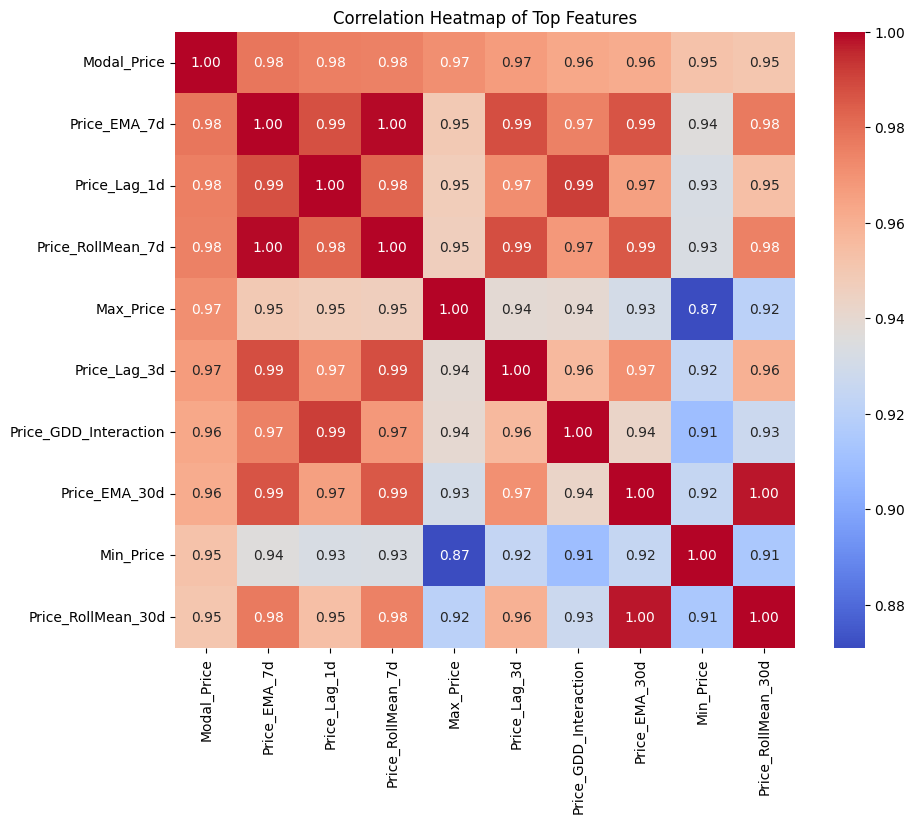

In [11]:
# Select numeric columns
numeric_cols = df_final_clean.select_dtypes(include=[np.number]).columns
correlation = df_final_clean[numeric_cols].corr()['Modal_Price'].sort_values(ascending=False)

print("Top Correlations with Modal_Price:")
print(correlation.head(10))
print("\nBottom Correlations with Modal_Price:")
print(correlation.tail(5))

# Heatmap of top features
top_features = correlation.head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_final_clean[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Top Features")
plt.show()

## 6. Feature Importance Analysis

Train a Random Forest model to determine the most important features for predicting `Modal_Price`.

Training Random Forest on 18340 samples with 89 features...
✅ Model Trained.
   RMSE: 214.65
   R² Score: 0.9971

Top 10 Important Features:
              Feature  Importance
10       Price_Lag_1d    0.526540
1           Max_Price    0.371612
19       Price_EMA_7d    0.068355
0           Min_Price    0.018795
74    Price_Change_1d    0.005599
78    Price_Range_Pct    0.002098
11       Price_Lag_3d    0.001525
75    Price_Change_7d    0.000826
15  Price_RollMean_7d    0.000753
6       DayOfYear_Cos    0.000464


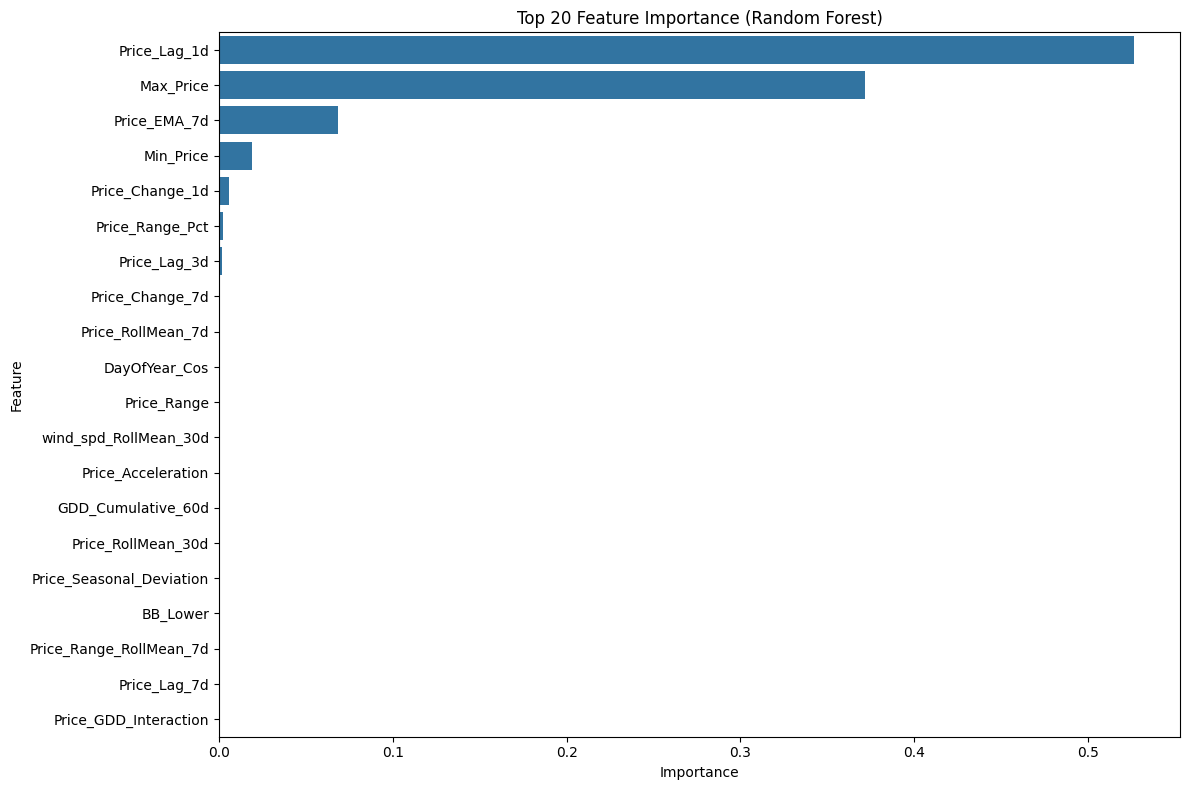

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Prepare Data for Modeling
# Drop non-numeric columns and target
target_col = 'Modal_Price'
drop_cols = ['Date', 'Commodity', 'Variety', 'Location_Key', 'Source_Mandi', 'Source_Location', target_col]

# Select features
feature_cols = [c for c in df_final_clean.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_final_clean[c])]

X = df_final_clean[feature_cols]
y = df_final_clean[target_col]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Random Forest on {X_train.shape[0]} samples with {X_train.shape[1]} features...")

# Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"✅ Model Trained.")
print(f"   RMSE: {rmse:.2f}")
print(f"   R² Score: {r2:.4f}")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
plt.title('Top 20 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [16]:
# Create Feature Descriptions Dictionary
feature_descriptions = {
    # Temporal Features
    'Month_Sin': 'Sine-encoded month (captures cyclical nature of months)',
    'Month_Cos': 'Cosine-encoded month (captures cyclical nature of months)',
    'DayOfYear_Sin': 'Sine-encoded day of year (captures annual seasonality)',
    'DayOfYear_Cos': 'Cosine-encoded day of year (captures annual seasonality)',
    'Year': 'Calendar year',
    'Month': 'Month number (1-12)',
    'WeekOfYear': 'Week number in the year',
    'DayOfWeek': 'Day of week (0=Monday, 6=Sunday)',
    'IsWeekend': 'Binary indicator for weekend (Saturday/Sunday)',
    'DayOfYear': 'Day number in the year (1-365)',
    
    # Price Lag Features
    'Price_Lag_1d': 'Modal price from 1 day ago',
    'Price_Lag_3d': 'Modal price from 3 days ago',
    'Price_Lag_7d': 'Modal price from 7 days ago (1 week)',
    'Price_Lag_14d': 'Modal price from 14 days ago (2 weeks)',
    'Price_Lag_30d': 'Modal price from 30 days ago (1 month)',
    
    # Rolling Statistics
    'Price_RollMean_7d': '7-day rolling average of price',
    'Price_RollMean_30d': '30-day rolling average of price',
    'Price_RollStd_7d': '7-day rolling standard deviation (short-term volatility)',
    'Price_RollStd_30d': '30-day rolling standard deviation (long-term volatility)',
    
    # Exponential Moving Averages
    'Price_EMA_7d': '7-day exponential moving average (weights recent prices higher)',
    'Price_EMA_30d': '30-day exponential moving average (trend indicator)',
    
    # Technical Indicators
    'Price_RSI_14d': 'Relative Strength Index (momentum: 0-100, >70 overbought, <30 oversold)',
    'BB_Upper': 'Bollinger Band upper bound (volatility band)',
    'BB_Lower': 'Bollinger Band lower bound (volatility band)',
    'BB_PctB': 'Bollinger %B (position within bands: 0=lower, 1=upper)',
    'MACD': 'Moving Average Convergence Divergence (trend strength)',
    'MACD_Signal': 'MACD signal line (9-day EMA of MACD)',
    
    # Price Dynamics
    'Price_Change_1d': 'Daily price change (velocity)',
    'Price_Change_7d': 'Weekly price change',
    'Price_Acceleration': 'Rate of change in price velocity',
    'Price_Range': 'Daily price range (Max - Min)',
    'Price_Range_Pct': 'Price range as percentage of modal price',
    'Price_Range_RollMean_7d': '7-day average of price range (market stability)',
    'Price_Seasonal_Deviation': 'Deviation from average price for this time of year',
    
    # Cross-Market Features
    'Price_Spread_Max': 'Maximum price difference across locations (arbitrage indicator)',
    'Price_Spread_Std': 'Standard deviation of prices across locations',
    
    # Weather - Temperature
    'temp': 'Daily average temperature (°C)',
    'temp_RollMean_7d': '7-day average temperature',
    'temp_RollMean_15d': '15-day average temperature',
    'temp_RollMean_30d': '30-day average temperature',
    'temp_RollMean_90d': '90-day average temperature (seasonal)',
    'temp_Anomaly_30d': 'Temperature deviation from 30-day average',
    
    # Weather - Precipitation
    'precip': 'Daily rainfall (mm)',
    'precip_RollMean_7d': '7-day cumulative rainfall',
    'precip_RollMean_15d': '15-day cumulative rainfall',
    'precip_RollMean_30d': '30-day cumulative rainfall',
    'precip_RollMean_90d': '90-day cumulative rainfall (growing season)',
    'precip_Anomaly_30d': 'Rainfall deviation from 30-day average',
    
    # Weather - Humidity
    'rh': 'Relative humidity (%)',
    'rh_RollMean_7d': '7-day average humidity',
    'rh_RollMean_15d': '15-day average humidity',
    'rh_RollMean_30d': '30-day average humidity',
    'rh_RollMean_90d': '90-day average humidity',
    'rh_Anomaly_30d': 'Humidity deviation from 30-day average',
    
    # Weather - Wind
    'wind_spd': 'Wind speed (m/s)',
    'wind_spd_RollMean_7d': '7-day average wind speed',
    'wind_spd_RollMean_15d': '15-day average wind speed',
    'wind_spd_RollMean_30d': '30-day average wind speed',
    'wind_spd_RollMean_90d': '90-day average wind speed',
    'wind_spd_Anomaly_30d': 'Wind speed deviation from 30-day average',
    
    # Weather - Solar Radiation
    'solar_rad': 'Solar radiation (W/m²)',
    'solar_rad_RollMean_7d': '7-day average solar radiation',
    'solar_rad_RollMean_15d': '15-day average solar radiation',
    'solar_rad_RollMean_30d': '30-day average solar radiation',
    'solar_rad_RollMean_90d': '90-day average solar radiation',
    'solar_rad_Anomaly_30d': 'Solar radiation deviation from 30-day average',
    
    # Agricultural Indices
    'GDD_Daily': 'Growing Degree Days (daily heat accumulation for crop growth)',
    'GDD_Cumulative_30d': '30-day cumulative GDD',
    'GDD_Cumulative_60d': '60-day cumulative GDD',
    'GDD_Cumulative_90d': '90-day cumulative GDD (full growing cycle)',
    'Consecutive_Dry_Days': 'Number of consecutive days with rainfall <1mm (drought indicator)',
    'Rainfall_Deficit_30d': 'Rainfall shortage compared to 30-day average',
    'Heatwave_Day': 'Binary indicator for extreme heat (temp >35°C)',
    'Heatwave_Count_30d': 'Number of heatwave days in last 30 days',
    'Heavy_Rain_Day': 'Binary indicator for heavy rainfall (>20mm/day)',
    'Heavy_Rain_Count_30d': 'Number of heavy rain days in last 30 days',
    'VPD': 'Vapor Pressure Deficit (plant water stress indicator, kPa)',
    'VPD_RollMean_30d': '30-day average VPD',
    'Low_Light_Day': 'Binary indicator for low solar radiation (<100 W/m²)',
    'Low_Light_Count_30d': 'Number of low light days in last 30 days',
    
    # Interaction Features
    'Heat_Index_Proxy': 'Temperature × Humidity (heat stress indicator)',
    'Storm_Index': 'Precipitation × Wind Speed (storm intensity indicator)',
    'Price_Drought_Interaction': 'Price × Consecutive Dry Days (drought impact on prices)',
    'Price_GDD_Interaction': 'Price × Cumulative GDD (growing season impact)',
    
    # Market Timing
    'Days_Since_Last_Record': 'Days elapsed since last market observation (data frequency indicator)',
    'Is_Dry_Day': 'Binary indicator for day with rainfall <1mm',
}

print(f"✅ Feature descriptions created for {len(feature_descriptions)} features")

✅ Feature descriptions created for 86 features


## 7. Generate Feature Engineering Report

Create a comprehensive HTML report summarizing the features, correlations, and importance.

In [17]:
import base64
from io import BytesIO
from datetime import datetime

def get_plot_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

print("⏳ Generating Comprehensive HTML Report...")

# 1. Generate Plots for Report
# Correlation Heatmap
plt.figure(figsize=(12, 10))
top_corr_features = correlation.head(15).index.tolist()
sns.heatmap(df_final_clean[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title("Top 15 Feature Correlations", fontsize=14, pad=10)
plt.tight_layout()
corr_plot_b64 = get_plot_base64(plt.gcf())
plt.close()

# Feature Importance Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20), palette='viridis')
plt.title('Top 20 Feature Importance (Random Forest)', fontsize=14, pad=10)
plt.xlabel('Importance Score')
plt.tight_layout()
imp_plot_b64 = get_plot_base64(plt.gcf())
plt.close()

# Feature Categories
all_features = feature_cols
price_features = [f for f in all_features if 'Price' in f or 'MACD' in f or 'RSI' in f or 'BB_' in f]
weather_features = [f for f in all_features if any(w in f for w in ['temp', 'precip', 'rh', 'wind', 'solar', 'GDD', 'VPD', 'Drought', 'Heatwave'])]
temporal_features = [f for f in all_features if any(t in f for t in ['Month', 'Year', 'Week', 'Day'])]
interaction_features = [f for f in all_features if 'Interaction' in f or 'Spread' in f or 'Index' in f]

# 2. HTML Content
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>AgriCast360 - Feature Engineering Report</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; line-height: 1.6; color: #333; background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%); }}
        .container {{ max-width: 1400px; margin: 0 auto; padding: 20px; }}
        h1, h2, h3 {{ color: #2c3e50; margin-bottom: 15px; }}
        .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 40px; border-radius: 12px; margin-bottom: 30px; text-align: center; box-shadow: 0 10px 30px rgba(0,0,0,0.2); }}
        .header h1 {{ font-size: 2.5em; margin-bottom: 10px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3); }}
        .header p {{ font-size: 1.2em; opacity: 0.95; }}
        .section {{ background: white; padding: 30px; border-radius: 12px; box-shadow: 0 4px 15px rgba(0,0,0,0.1); margin-bottom: 25px; }}
        .stats-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; margin-bottom: 25px; }}
        .stat-card {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 25px; border-radius: 10px; text-align: center; box-shadow: 0 4px 10px rgba(0,0,0,0.15); transition: transform 0.3s; }}
        .stat-card:hover {{ transform: translateY(-5px); }}
        .stat-value {{ font-size: 32px; font-weight: bold; margin-bottom: 8px; }}
        .stat-label {{ font-size: 14px; opacity: 0.9; }}
        .feature-category {{ background: #f8f9fa; padding: 20px; border-radius: 8px; margin-bottom: 15px; border-left: 5px solid #667eea; }}
        .feature-list {{ columns: 2; column-gap: 20px; }}
        .feature-item {{ padding: 5px 0; break-inside: avoid; }}
        table {{ width: 100%; border-collapse: collapse; margin-top: 15px; }}
        th, td {{ padding: 12px; text-align: left; border-bottom: 1px solid #ddd; }}
        th {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; font-weight: 600; }}
        tr:hover {{ background-color: #f5f5f5; }}
        img {{ max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #ddd; margin: 20px 0; box-shadow: 0 4px 10px rgba(0,0,0,0.1); }}
        .highlight {{ background: linear-gradient(120deg, #84fab0 0%, #8fd3f4 100%); padding: 15px; border-radius: 8px; margin: 15px 0; }}
        .footer {{ text-align: center; margin-top: 50px; padding: 20px; color: #7f8c8d; font-size: 12px; }}
        .metric-badge {{ display: inline-block; background: #27ae60; color: white; padding: 5px 15px; border-radius: 20px; margin: 5px; font-weight: bold; }}
        ul {{ margin-left: 20px; }}
        li {{ margin: 8px 0; }}
    </style>
</head>
<body>
<div class="container">

<div class="header">
    <h1>AgriCast360 - Feature Engineering Report</h1>
    <p>Advanced Feature Construction & Analysis for Agricultural Price Prediction</p>
    <p style="font-size: 0.9em; margin-top: 10px;">Generated: {datetime.now().strftime('%B %d, %Y at %H:%M')}</p>
</div>

<div class="section">
    <h2>Dataset Overview</h2>
    <div class="stats-grid">
        <div class="stat-card">
            <div class="stat-value">{df_final_clean.shape[0]:,}</div>
            <div class="stat-label">Total Samples</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">{df_final_clean.shape[1]}</div>
            <div class="stat-label">Total Features</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">{len(df_final_clean['Location_Key'].unique())}</div>
            <div class="stat-label">Markets</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">{len(df_final_clean['Commodity'].unique())}</div>
            <div class="stat-label">Commodities</div>
        </div>
    </div>
    
    <div class="highlight">
        <strong>Model Performance:</strong>
        <span class="metric-badge">R² Score: {r2:.4f}</span>
        <span class="metric-badge">RMSE: {rmse:.2f}</span>
    </div>
</div>

<div class="section">
    <h2>Feature Engineering Summary</h2>
    <p>A comprehensive set of <strong>{len(feature_cols)}</strong> features engineered across multiple dimensions:</p>
    
    <div class="feature-category">
        <h3>Price & Market Features ({len(price_features)})</h3>
        <div class="feature-list">
            <div class="feature-item">Lag Features (1d, 3d, 7d, 14d, 30d)</div>
            <div class="feature-item">Rolling Statistics (Mean, Std, EMA)</div>
            <div class="feature-item">RSI (Relative Strength Index)</div>
            <div class="feature-item">MACD (Trend Indicator)</div>
            <div class="feature-item">Bollinger Bands (Volatility)</div>
            <div class="feature-item">Price Momentum & Acceleration</div>
            <div class="feature-item">Price Range & Spread Analysis</div>
            <div class="feature-item">Cross-Market Arbitrage Indicators</div>
        </div>
    </div>
    
    <div class="feature-category">
        <h3>Weather Features ({len(weather_features)})</h3>
        <div class="feature-list">
            <div class="feature-item">Rolling Averages (7, 15, 30, 90 days)</div>
            <div class="feature-item">Weather Anomalies (Temp, Rainfall, etc.)</div>
            <div class="feature-item">Growing Degree Days (GDD)</div>
            <div class="feature-item">Drought Stress Index</div>
            <div class="feature-item">Consecutive Dry/Wet Days</div>
            <div class="feature-item">Vapor Pressure Deficit (VPD)</div>
            <div class="feature-item">Extreme Weather Events (Heatwaves, Heavy Rain)</div>
            <div class="feature-item">Solar Radiation Stress</div>
        </div>
    </div>
    
    <div class="feature-category">
        <h3>Temporal Features ({len(temporal_features)})</h3>
        <div class="feature-list">
            <div class="feature-item">Cyclical Encoding (Sin/Cos)</div>
            <div class="feature-item">Month, Year, Week of Year</div>
            <div class="feature-item">Day of Week, Weekend Indicator</div>
            <div class="feature-item">Seasonal Deviation</div>
        </div>
    </div>
    
    <div class="feature-category">
        <h3>Interaction Features ({len(interaction_features)})</h3>
        <div class="feature-list">
            <div class="feature-item">Price x Drought Interaction</div>
            <div class="feature-item">Price x GDD Interaction</div>
            <div class="feature-item">Heat Index Proxy (Temp x Humidity)</div>
            <div class="feature-item">Storm Index (Rain x Wind)</div>
        </div>
    </div>
</div>

<div class="section">
    <h2>Top 20 Most Important Features</h2>
    <p>Features ranked by their contribution to model predictions (Random Forest feature importance).</p>
    <img src="data:image/png;base64,{imp_plot_b64}" alt="Feature Importance Plot">
    
    <h3>Detailed Feature Importance with Descriptions</h3>
    <table>
        <thead>
            <tr>
                <th>Rank</th>
                <th>Feature</th>
                <th>Importance</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            {''.join([f'''
            <tr>
                <td>{i+1}</td>
                <td><strong>{row["Feature"]}</strong></td>
                <td>{row["Importance"]:.6f}</td>
                <td>{feature_descriptions.get(row["Feature"], "Feature description not available")}</td>
            </tr>''' for i, row in feature_importance.head(20).iterrows()])}
        </tbody>
    </table>
</div>

<div class="section">
    <h2>Correlation Analysis</h2>
    <p>Examining relationships between top features and the target variable (Modal_Price).</p>
    <img src="data:image/png;base64,{corr_plot_b64}" alt="Correlation Heatmap">
    
    <div class="highlight">
        <h3>Key Insights:</h3>
        <ul>
            <li><strong>Strongest Positive Correlations:</strong> {', '.join(correlation.head(3).index[1:].tolist())}</li>
            <li><strong>Most Important by RF Model:</strong> {', '.join(feature_importance.head(3)['Feature'].tolist())}</li>
            <li><strong>Feature Categories Represented:</strong> Price Dynamics, Weather Impact, Market Behavior</li>
        </ul>
    </div>
</div>

<div class="section">
    <h2>Feature Engineering Methodology</h2>
    <h3>1. Agricultural Domain Knowledge</h3>
    <ul>
        <li><strong>Growing Degree Days (GDD):</strong> Accumulated heat units critical for crop development stages.</li>
        <li><strong>Drought Stress:</strong> Consecutive dry days and rainfall deficit impact yield and thus supply.</li>
        <li><strong>Vapor Pressure Deficit (VPD):</strong> Indicates atmospheric demand for water, affecting crop water stress.</li>
        <li><strong>Extreme Weather Events:</strong> Heatwaves and heavy rainfall directly impact crop quality and market supply.</li>
    </ul>
    
    <h3>2. Financial Market Techniques</h3>
    <ul>
        <li><strong>Technical Indicators:</strong> RSI, MACD, and Bollinger Bands borrowed from financial analysis.</li>
        <li><strong>Momentum Features:</strong> Price velocity and acceleration capture market dynamics.</li>
        <li><strong>Cross-Market Arbitrage:</strong> Price spreads indicate market inefficiencies and transportation costs.</li>
    </ul>
    
    <h3>3. Time Series Engineering</h3>
    <ul>
        <li><strong>Cyclical Encoding:</strong> Sin/Cos transformation preserves seasonal patterns.</li>
        <li><strong>Multi-Window Rolling Features:</strong> Capture both short-term and long-term trends.</li>
        <li><strong>Lag Features:</strong> Autoregressive patterns from 1 to 30 days.</li>
    </ul>
</div>

<div class="section">
    <h2>Complete Feature Catalog</h2>
    <p>Comprehensive list of all {len(feature_cols)} engineered features with descriptions.</p>
    
    <h3>Price & Market Features</h3>
    <table>
        <thead>
            <tr>
                <th>Feature Name</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            {''.join([f'''
            <tr>
                <td><strong>{feat}</strong></td>
                <td>{feature_descriptions.get(feat, "Price/Market feature")}</td>
            </tr>''' for feat in sorted(price_features)[:30]])}
        </tbody>
    </table>
    
    <h3>Weather Features</h3>
    <table>
        <thead>
            <tr>
                <th>Feature Name</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            {''.join([f'''
            <tr>
                <td><strong>{feat}</strong></td>
                <td>{feature_descriptions.get(feat, "Weather feature")}</td>
            </tr>''' for feat in sorted(weather_features)[:30]])}
        </tbody>
    </table>
    
    <h3>Temporal Features</h3>
    <table>
        <thead>
            <tr>
                <th>Feature Name</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            {''.join([f'''
            <tr>
                <td><strong>{feat}</strong></td>
                <td>{feature_descriptions.get(feat, "Temporal feature")}</td>
            </tr>''' for feat in sorted(temporal_features)])}
        </tbody>
    </table>
    
    <h3>Interaction Features</h3>
    <table>
        <thead>
            <tr>
                <th>Feature Name</th>
                <th>Description</th>
            </tr>
        </thead>
        <tbody>
            {''.join([f'''
            <tr>
                <td><strong>{feat}</strong></td>
                <td>{feature_descriptions.get(feat, "Interaction feature")}</td>
            </tr>''' for feat in sorted(interaction_features)])}
        </tbody>
    </table>
</div>

<div class="footer">
    <p><strong>AgriCast360 Project</strong> | Feature Engineering Pipeline</p>
    <p>Powered by Python, Pandas, Scikit-Learn, and Agricultural Science</p>
</div>

</div>
</body>
</html>
"""

# Save Report
report_path = EDA_RESULTS_FOLDER / "AgriCast360_Feature_Engineering_Report.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"\n{'='*60}")
print(f"✅ REPORT GENERATED SUCCESSFULLY!")
print(f"{'='*60}")
print(f"📄 Location: {report_path}")
print(f"📊 Total Features: {len(feature_cols)}")
print(f"   - Price Features: {len(price_features)}")
print(f"   - Weather Features: {len(weather_features)}")
print(f"   - Temporal Features: {len(temporal_features)}")
print(f"   - Interaction Features: {len(interaction_features)}")
print(f"🎯 Model R² Score: {r2:.4f}")
print(f"{'='*60}")

⏳ Generating Comprehensive HTML Report...

✅ REPORT GENERATED SUCCESSFULLY!
📄 Location: D:\CUDA_Experiments\Git_HUB\Machine-Learning\AgriCast360\AgriCast360_V2\EDA_Results\AgriCast360_Feature_Engineering_Report.html
📊 Total Features: 89
   - Price Features: 30
   - Weather Features: 40
   - Temporal Features: 16
   - Interaction Features: 6
🎯 Model R² Score: 0.9971
